In [35]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



1. Extracting Data

In [36]:
tickers = "MSFT"
start_date = '2021-12-31'
end_date = '2026-01-01'
benchmark = "QQQ"

def pull_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df = df[["Open", "High", "Low", "Close", "Volume"]]
    df.dropna(inplace=True)
    return df

stock = pull_data(tickers, start_date, end_date)
bench = pull_data(benchmark, start_date, end_date)

print(stock.shape)
print(stock.head())
print(bench.head())

/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed
/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

(1004, 5)
Price             Open        High         Low       Close    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2021-12-31  326.790575  327.611124  324.222662  324.676392  18000800
2022-01-03  323.740000  326.298250  318.362830  323.160767  28865100
2022-01-04  323.237993  323.595208  314.829546  317.619507  32674300
2022-01-05  314.578536  314.781287  305.040612  305.426758  40054300
2022-01-06  302.308568  307.666442  300.706035  303.013306  39646100
Price             Open        High         Low       Close    Volume
Ticker             QQQ         QQQ         QQQ         QQQ       QQQ
Date                                                                
2021-12-31  389.709759  391.074897  387.447512  387.944824  34752900
2022-01-03  389.114948  391.933010  386.998990  391.679474  40575900
2022-01-04  392.225517  392.264530  383.498361  386.599182  58027200
2022-01-05  384.912254  

In [37]:
stocks_df = stock.xs(tickers, axis=1, level=1)
stocks_df.columns.names = [None] * len(stocks_df.columns.names)
stocks_df

,Open,High,Low,Close,Volume
Date,,,,,
2021-12-31,326.790575,327.611124,324.222662,324.676392,18000800
2022-01-03,323.740000,326.298250,318.362830,323.160767,28865100
2022-01-04,323.237993,323.595208,314.829546,317.619507,32674300
2022-01-05,314.578536,314.781287,305.040612,305.426758,40054300
2022-01-06,302.308568,307.666442,300.706035,303.013306,39646100
...,...,...,...,...,...
2025-12-24,484.573963,488.046049,483.725892,486.908630,5855900
2025-12-26,485.601642,487.008435,484.853350,486.599365,8842200
2025-12-29,483.755834,487.237907,483.077389,485.990753,10893400


In [38]:
bench_df = bench.xs(benchmark, axis=1, level=1)
bench_df.columns.names = [None] * len(bench_df.columns.names)
bench_df

,Open,High,Low,Close,Volume
Date,,,,,
2021-12-31,389.709759,391.074897,387.447512,387.944824,34752900
2022-01-03,389.114948,391.933010,386.998990,391.679474,40575900
2022-01-04,392.225517,392.264530,383.498361,386.599182,58027200
2022-01-05,384.912254,386.033646,374.468906,374.722443,75739800
2022-01-06,372.899087,377.706340,370.666091,374.459229,70814300
...,...,...,...,...,...
2025-12-24,621.989990,624.280029,621.719971,623.929993,18468700
2025-12-26,624.659973,625.520020,623.140015,623.890015,28959800
2025-12-29,620.099976,622.780029,618.729980,620.869995,32458300


2. Ratios

In [73]:
basic_ratios = pd.Series()
stock = yf.Ticker("MSFT")   
info = stock.info      
basic_ratios['pe_trailing']  = info.get("trailingPE")
basic_ratios['pe_forward']  = info.get("forwardPE")
basic_ratios['pb']          = info.get("priceToBook")
basic_ratios['ps ']         = info.get("priceToSalesTrailing12Months")
basic_ratios['roe']         = info.get("returnOnEquity")   
basic_ratios['roa ']        = info.get("returnOnAssets")
basic_ratios

/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/quote.py:700: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  start = pd.Timestamp.utcnow().floor("D") - datetime.timedelta(days=365 // 2)
/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/quote.py:702: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")


pe_trailing    23.203245
pe_forward     19.682241
pb              7.051599
ps              9.027772
roe             0.343910
roa             0.148600
dtype: float64

In [69]:
# Income statement, balance sheet (annual, wide format)
income = stock.financials      # rows = line items, cols = periods
balance = stock.balance_sheet

# Transpose to have rows as dates (optional but convenient)
income = income.T
balance = balance.T

#few core ratios per year
ratios = pd.DataFrame()
# Profitability
ratios["Net Profit Margin"] = income["Net Income"] / income["Total Revenue"]
ratios["Operating Margin"]  = income["Operating Income"] / income["Total Revenue"]

# Leverage
ratios["Debt to Equity"] = balance["Total Debt"] / balance["Stockholders Equity"]

# Liquidity
ratios["Current Ratio"] = (balance["Total Assets"] - balance["Total Non Current Assets"])/ balance["Current Liabilities"]

# Efficiency (asset turnover)
ratios["Asset Turnover"] = income["Total Revenue"] / balance["Total Assets"]

print(pd.DataFrame(ratios))

            Net Profit Margin  Operating Margin  Debt to Equity  \
2025-06-30           0.361460          0.456220        0.176395   
2024-06-30           0.359560          0.446443        0.250029   
2023-06-30           0.341462          0.417729        0.290777   
2022-06-30           0.366863          0.420553        0.367895   

            Current Ratio  Asset Turnover  
2025-06-30       1.353446        0.455125  
2024-06-30       1.274955        0.478602  
2023-06-30       1.769167        0.514387  
2022-06-30       1.784607        0.543444  


/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/opt/anaconda3/lib/python3.13/site-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")


3. Daily Price Movement

/var/folders/q0/424zw2ns4w308pm49_mffm4h0000gn/T/ipykernel_16672/347647308.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


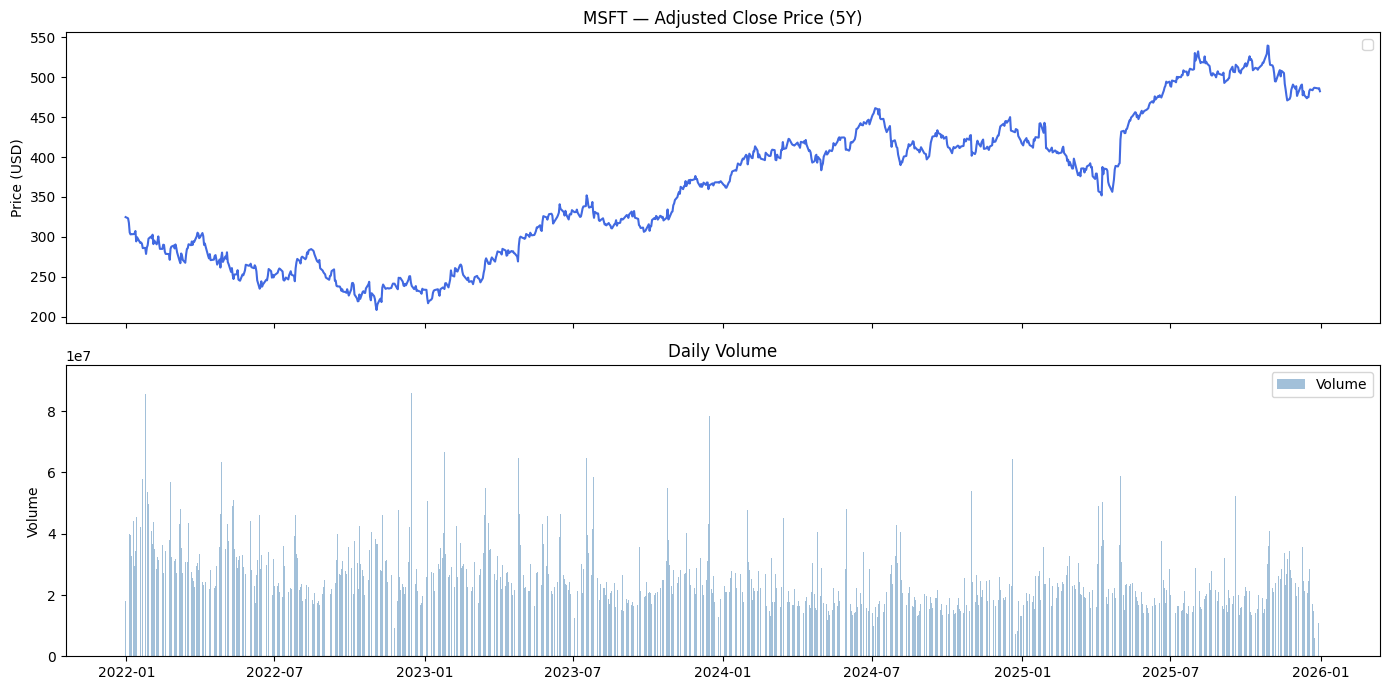

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(stocks_df["Close"], color="royalblue")
ax1.set_title(f"{tickers} — Adjusted Close Price (5Y)")
ax1.set_ylabel("Price (USD)")
ax1.legend()

ax2.bar(stocks_df.index, stocks_df["Volume"], color="steelblue", alpha=0.5, label="Volume")
ax2.set_ylabel("Volume")
ax2.set_title("Daily Volume")
ax2.legend()

plt.tight_layout()
plt.show()

In [42]:
stocks_df["Daily_return"] = stocks_df["Close"].pct_change()
bench_df["Daily_return"] = bench_df["Close"].pct_change()

# Drop first row (NaN from pct_change)
stocks_df.dropna(inplace=True)
bench_df.dropna(inplace=True)

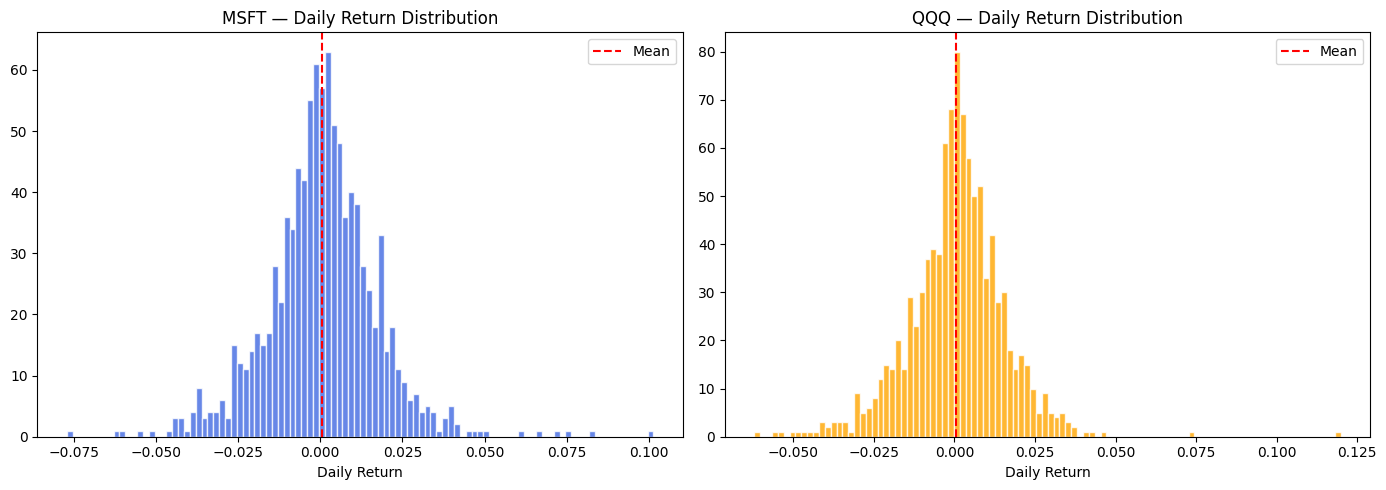

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(stocks_df["Daily_return"], bins=100, color="royalblue", edgecolor="white", alpha=0.8)
axes[0].set_title(f"{tickers} — Daily Return Distribution")
axes[0].set_xlabel("Daily Return")
axes[0].axvline(stocks_df["Daily_return"].mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

axes[1].hist(bench_df["Daily_return"], bins=100, color="orange", edgecolor="white", alpha=0.8)
axes[1].set_title(f"{benchmark} — Daily Return Distribution")
axes[1].set_xlabel("Daily Return")
axes[1].axvline(bench_df["Daily_return"].mean(), color="red", linestyle="--", label="Mean")
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
stocks_df["Cum_return"] = (stocks_df["Close"].pct_change()+1).cumprod()-1
bench_df["Cum_return"] = (bench_df["Close"].pct_change()+1).cumprod()-1
stocks_df.dropna(inplace=True)
bench_df.dropna(inplace=True)

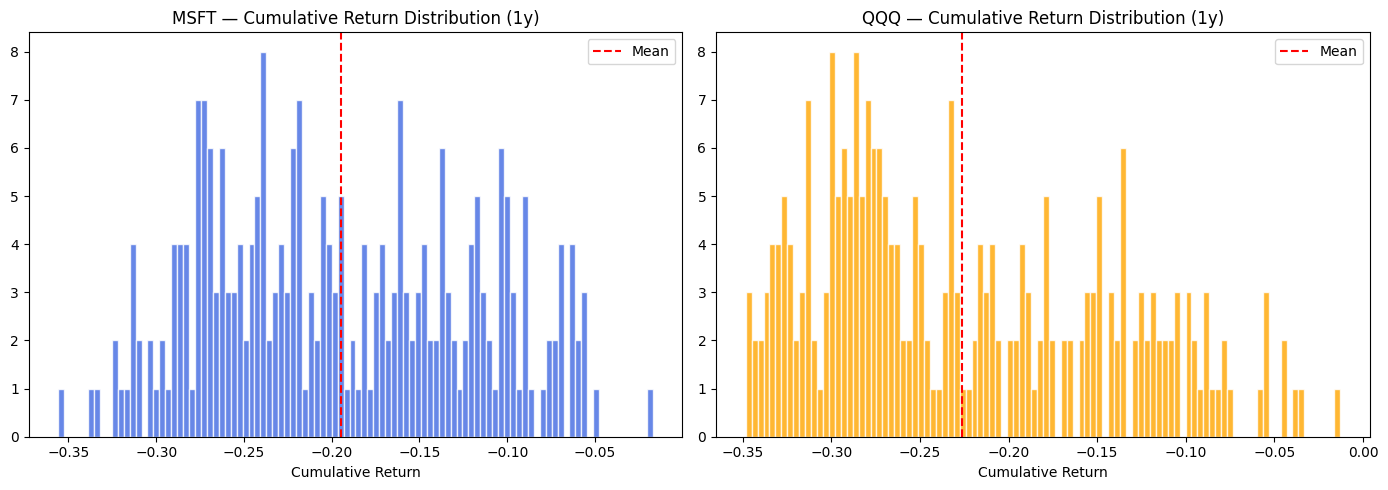

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(stocks_df.iloc[:252]["Cum_return"], bins=100, color="royalblue", edgecolor="white", alpha=0.8)
axes[0].set_title(f"{tickers} — Cumulative Return Distribution (1y)")
axes[0].set_xlabel("Cumulative Return")
axes[0].axvline(stocks_df.iloc[:252]["Cum_return"].mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

axes[1].hist(bench_df.iloc[:252]["Cum_return"], bins=100, color="orange", edgecolor="white", alpha=0.8)
axes[1].set_title(f"{benchmark} — Cumulative Return Distribution (1y)")
axes[1].set_xlabel("Cumulative Return")
axes[1].axvline(bench_df.iloc[:252]["Cum_return"].mean(), color="red", linestyle="--", label="Mean")
axes[1].legend()

plt.tight_layout()
plt.show()

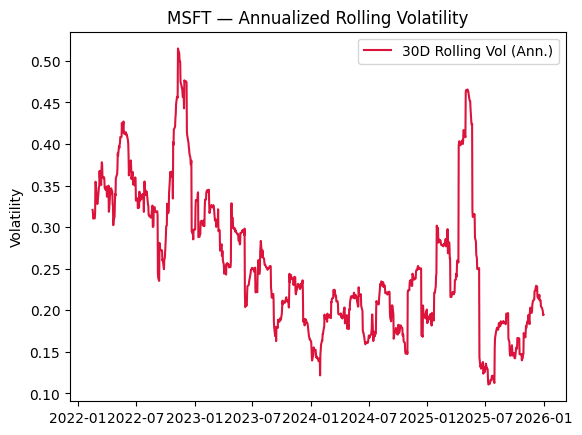

In [46]:
stocks_df["rolling_vol_30"] = stocks_df["Daily_return"].rolling(30).std() * np.sqrt(252)

plt.plot(stocks_df["rolling_vol_30"], color="crimson", label="30D Rolling Vol (Ann.)")
plt.title(f"{tickers} — Annualized Rolling Volatility")
plt.ylabel("Volatility")
plt.legend()
plt.show()

4. Return Ratios

In [47]:
combined = stocks_df[["Close", "Daily_return"]].join(
    bench_df[["Close", "Daily_return"]].rename(columns={
        "Close": "Bench_close",
        "Daily_return": "Bench_return"}),how="inner")

print(combined.shape)
print(combined.head())

(1002, 4)
                 Close  Daily_return  Bench_close  Bench_return
Date                                                           
2022-01-04  317.619507     -0.017147   386.599182     -0.012971
2022-01-05  305.426758     -0.038388   374.722443     -0.030721
2022-01-06  303.013306     -0.007902   374.459229     -0.000702
2022-01-07  303.167786      0.000510   370.402679     -0.010833
2022-01-10  303.389893      0.000733   370.646515      0.000658


Sharpe = (Mean Return - Risk Free Rate) / Std of Returns, annualized

In [48]:
RISK_FREE_RATE = 0.05  

def sharpe_ratio(returns, rf=RISK_FREE_RATE):
    rf_daily = rf / 252
    excess = returns - rf_daily
    return (excess.mean() / excess.std()) * np.sqrt(252)

sharpe = sharpe_ratio(stocks_df["Daily_return"])
print(f"Sharpe Ratio ({tickers}): {sharpe:.4f}")

Sharpe Ratio (MSFT): 0.3233


Like Sharpe but only penalizes downside volatility - more realistic for equity research.

In [49]:
def sortino_ratio(returns, rf=RISK_FREE_RATE):
    rf_daily = rf / 252
    excess = returns - rf_daily
    downside = excess[excess < 0].std()
    return (excess.mean() / downside) * np.sqrt(252)

sortino = sortino_ratio(stocks_df["Daily_return"])
print(f"Sortino Ratio ({tickers}): {sortino:.4f}")

Sortino Ratio (MSFT): 0.4787


Calmar = Annualized Return / Max Drawdown — measures return per unit of your worst loss.

In [50]:
def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = (prices - roll_max) / roll_max
    return drawdown.min()  # most negative value

def calmar_ratio(returns, prices):
    ann_return = (1 + returns.mean()) ** 252 - 1
    mdd = abs(max_drawdown(prices))
    return ann_return / mdd

calmar = calmar_ratio(stocks_df["Daily_return"], stocks_df["Close"])
mdd = max_drawdown(stocks_df["Close"])

print(f"Max Drawdown  ({tickers}): {mdd:.2%}")
print(f"Calmar Ratio  ({tickers}): {calmar:.4f}")

Max Drawdown  (MSFT): -34.45%
Calmar Ratio  (MSFT): 0.4246


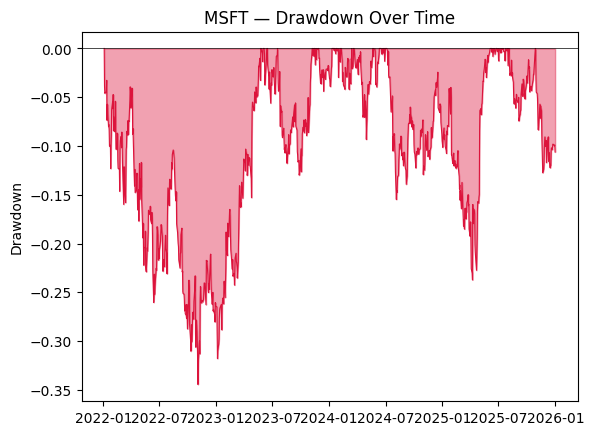

In [51]:
roll_max = stocks_df["Close"].cummax()
drawdown = (stocks_df["Close"] - roll_max) / roll_max

plt.fill_between(drawdown.index, drawdown, 0, color="crimson", alpha=0.4)
plt.plot(drawdown, color="crimson", linewidth=0.8)
plt.title(f"{tickers} — Drawdown Over Time")
plt.ylabel("Drawdown")
plt.axhline(0, color="black", linewidth=0.5)
plt.show()

5. Alpha & Beta vs QQQ

In [52]:
def compute_beta(stock_returns, bench_returns):
    cov_matrix = np.cov(stock_returns, bench_returns)
    beta = cov_matrix[0, 1] / cov_matrix[1, 1]
    return beta

beta = compute_beta(combined["Daily_return"].values,combined["Bench_return"].values)

print(f"Beta vs {benchmark}: {beta:.4f}")

Beta vs QQQ: 0.9222


Alpha (Jensen's Alpha)

Alpha = Stock Return - (Rf + Beta × (Benchmark Return - Rf))
Positive alpha means the stock outperformed what its risk level predicts.

In [53]:
def compute_alpha(stock_returns, bench_returns, beta, rf=RISK_FREE_RATE):
    rf_daily = rf / 252
    ann_stock = (1 + stock_returns.mean()) ** 252 - 1
    ann_bench = (1 + bench_returns.mean()) ** 252 - 1
    alpha = ann_stock - (rf + beta * (ann_bench - rf))
    return alpha

alpha = compute_alpha(combined["Daily_return"],combined["Bench_return"],beta)

print(f"Jensen's Alpha vs {benchmark}: {alpha:.4f}")

Jensen's Alpha vs QQQ: 0.0026


OLS Regression (full picture)

Confirms alpha & beta with statistical significance (p-values, R²)

In [54]:
from scipy import stats 
slope, intercept, r_value, p_value, std_err = stats.linregress(combined["Bench_return"],combined["Daily_return"])

print(f"\nOLS Regression: {tickers} ~ {benchmark}")
print(f"  Beta (slope)   : {slope:.4f}")
print(f"  Alpha (intercept annualized): {intercept * 252:.4f}")
print(f"  R²             : {r_value**2:.4f}")
print(f"  P-value        : {p_value:.6f}")


OLS Regression: MSFT ~ QQQ
  Beta (slope)   : 0.9222
  Alpha (intercept annualized): 0.0064
  R²             : 0.6650
  P-value        : 0.000000


Scatter Plot: Stock vs Benchmark Returns

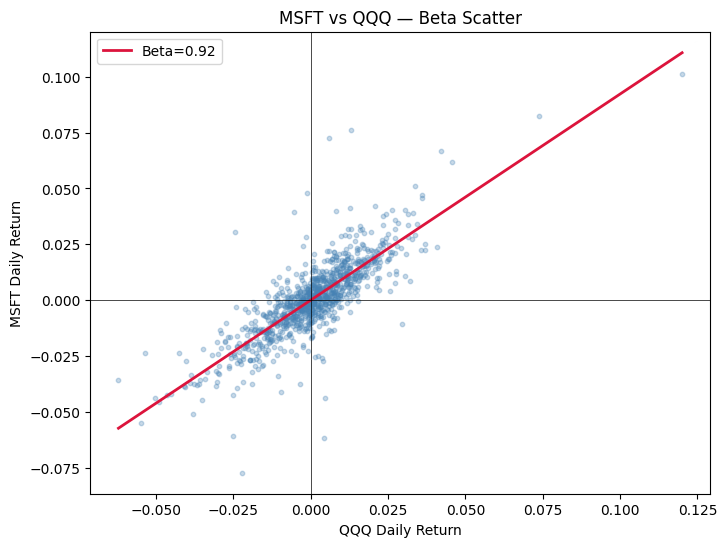

In [55]:
plt.figure(figsize=(8, 6))
plt.scatter(combined["Bench_return"], combined["Daily_return"],
            alpha=0.3, color="steelblue", s=10)

# Regression line
x_line = np.linspace(combined["Bench_return"].min(), combined["Bench_return"].max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color="crimson", linewidth=2, label=f"Beta={slope:.2f}")

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel(f"{benchmark} Daily Return")
plt.ylabel(f"{tickers} Daily Return")
plt.title(f"{tickers} vs {benchmark} — Beta Scatter")
plt.legend()
plt.show()

Full Summary Table

In [56]:
summary = {
    "Ticker": tickers,
    "Benchmark": benchmark,
    "Sharpe Ratio": round(sharpe, 4),
    "Sortino Ratio": round(sortino, 4),
    "Max Drawdown": f"{mdd:.2%}",
    "Calmar Ratio": round(calmar, 4),
    "Beta": round(beta, 4),
    "Jensen's Alpha": round(alpha, 4),
    "R²": round(r_value**2, 4),
}

for k, v in summary.items():
    print(f"{k:<20}: {v}")

Ticker              : MSFT
Benchmark           : QQQ
Sharpe Ratio        : 0.3233
Sortino Ratio       : 0.4787
Max Drawdown        : -34.45%
Calmar Ratio        : 0.4246
Beta                : 0.9222
Jensen's Alpha      : 0.0026
R²                  : 0.665


Rolling Beta

Instead of one static beta over 5 years, we compute it on a rolling 60-day window to see how the stock's sensitivity to QQQ shifts.

In [57]:
window = 60  # trading days (~3 months)

def rolling_beta(stock_returns, bench_returns, window):
    betas = []
    dates = []
    for i in range(window, len(stock_returns)):
        s = stock_returns.iloc[i-window:i]
        b = bench_returns.iloc[i-window:i]
        cov = np.cov(s, b)
        beta = cov[0, 1] / cov[1, 1]
        betas.append(beta)
        dates.append(stock_returns.index[i])
    return pd.Series(betas, index=dates, name="rolling_beta")

roll_beta = rolling_beta(combined["Daily_return"], combined["Bench_return"], window)

Rolling Alpha

Annualized alpha computed over the same rolling window.



In [58]:
def rolling_alpha(stock_returns, bench_returns, window, rf=RISK_FREE_RATE):
    alphas = []
    dates = []
    rf_daily = rf / 252
    for i in range(window, len(stock_returns)):
        s = stock_returns.iloc[i-window:i]
        b = bench_returns.iloc[i-window:i]
        cov = np.cov(s, b)
        beta = cov[0, 1] / cov[1, 1]
        alpha = (s.mean() - rf_daily) - beta * (b.mean() - rf_daily)
        alphas.append(alpha * 252)  # annualize
        dates.append(stock_returns.index[i])
    return pd.Series(alphas, index=dates, name="rolling_alpha")

roll_alpha = rolling_alpha(combined["Daily_return"], combined["Bench_return"], window)

Rolling Sharpe

In [59]:
def rolling_sharpe(returns, window, rf=RISK_FREE_RATE):
    rf_daily = rf / 252
    excess = returns - rf_daily
    roll_mean = excess.rolling(window).mean()
    roll_std = excess.rolling(window).std()
    return (roll_mean / roll_std * np.sqrt(252)).rename("rolling_sharpe")

roll_sharpe = rolling_sharpe(combined["Daily_return"], window)

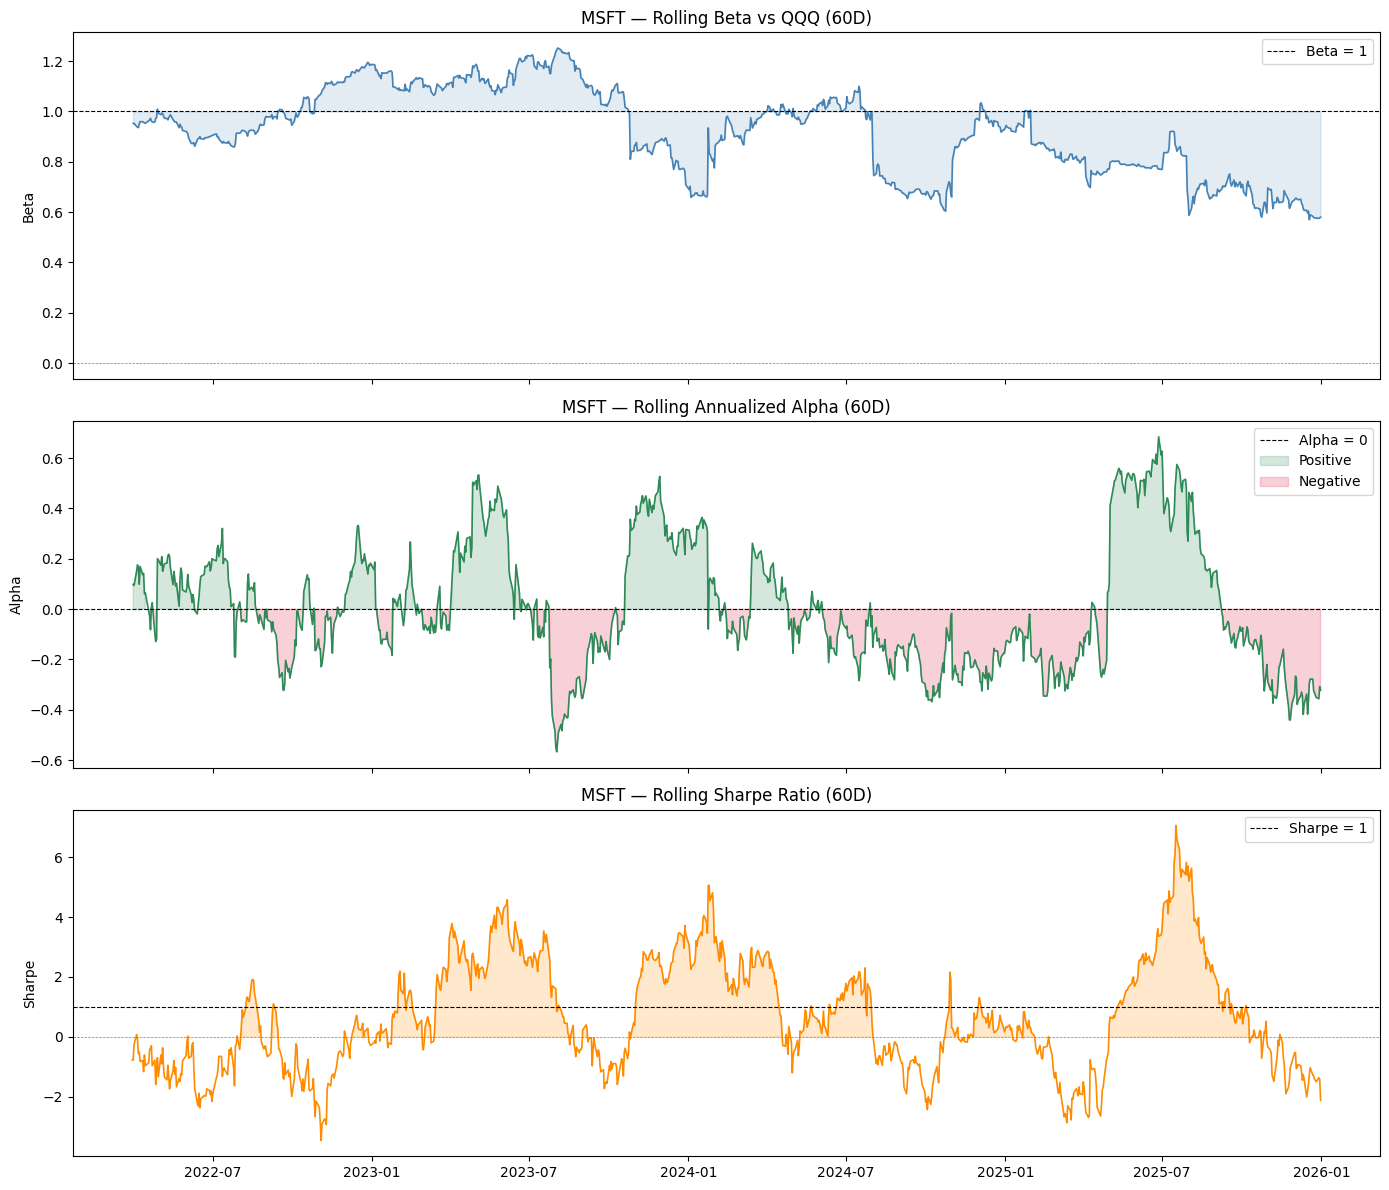

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Rolling Beta
axes[0].plot(roll_beta, color="steelblue", linewidth=1.2)
axes[0].axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="Beta = 1")
axes[0].axhline(0.0, color="gray", linestyle="--", linewidth=0.5)
axes[0].fill_between(roll_beta.index, roll_beta, 1, alpha=0.15, color="steelblue")
axes[0].set_title(f"{tickers} — Rolling Beta vs {benchmark} ({window}D)")
axes[0].set_ylabel("Beta")
axes[0].legend()

# Rolling Alpha
axes[1].plot(roll_alpha, color="seagreen", linewidth=1.2)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.8, label="Alpha = 0")
axes[1].fill_between(roll_alpha.index, roll_alpha, 0,
                     where=roll_alpha >= 0, alpha=0.2, color="seagreen", label="Positive")
axes[1].fill_between(roll_alpha.index, roll_alpha, 0,
                     where=roll_alpha < 0, alpha=0.2, color="crimson", label="Negative")
axes[1].set_title(f"{tickers} — Rolling Annualized Alpha ({window}D)")
axes[1].set_ylabel("Alpha")
axes[1].legend()

# Rolling Sharpe
axes[2].plot(roll_sharpe, color="darkorange", linewidth=1.2)
axes[2].axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="Sharpe = 1")
axes[2].axhline(0.0, color="gray", linestyle="--", linewidth=0.5)
axes[2].fill_between(roll_sharpe.index, roll_sharpe, 0,
                     where=roll_sharpe >= 0, alpha=0.2, color="darkorange")
axes[2].set_title(f"{tickers} — Rolling Sharpe Ratio ({window}D)")
axes[2].set_ylabel("Sharpe")
axes[2].legend()

plt.tight_layout()
plt.show()

Regime Table: When Was Alpha Positive?

This summarizes what % of the time the stock was generating positive alpha - useful for spotting regimes.

In [61]:
alpha_positive = (roll_alpha > 0).sum() / len(roll_alpha)
alpha_mean = roll_alpha.mean()
beta_mean = roll_beta.mean()
beta_gt1 = (roll_beta > 1).sum() / len(roll_beta)

print(f"\nRolling Analysis Summary — {tickers} vs {benchmark}")
print(f"{'='*45}")
print(f"Avg Rolling Alpha      : {alpha_mean:.4f}")
print(f"% Time Alpha > 0       : {alpha_positive:.2%}")
print(f"Avg Rolling Beta       : {beta_mean:.4f}")
print(f"% Time Beta > 1        : {beta_gt1:.2%}")


Rolling Analysis Summary — MSFT vs QQQ
Avg Rolling Alpha      : 0.0067
% Time Alpha > 0       : 42.46%
Avg Rolling Beta       : 0.9207
% Time Beta > 1        : 34.71%


Rolling Beta > 1 = Stock amplifies QQQ — higher risk periods

Rolling Beta < 1 = Stock defensive relative to QQQ

Rolling Alpha > 0 = Stock generating excess return above risk-adjusted benchmark

Rolling Alpha < 0 = Stock underperforming for its risk level

Rolling Sharpe dips = Periods of poor risk-adjusted performance

Cumulative Returns

How $1 invested in the stock vs QQQ grew over 5 years.

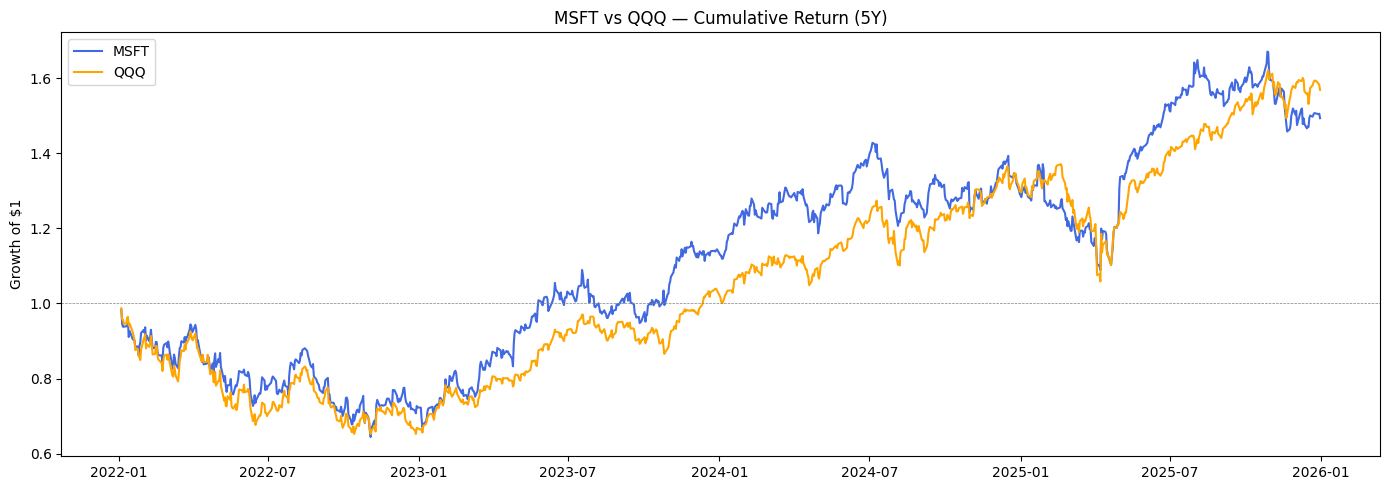

In [62]:
combined["Cum_stock"] = (1 + combined["Daily_return"]).cumprod()
combined["Cum_bench"] = (1 + combined["Bench_return"]).cumprod()

plt.figure(figsize=(14, 5))
plt.plot(combined["Cum_stock"], color="royalblue", linewidth=1.5, label=tickers)
plt.plot(combined["Cum_bench"], color="orange", linewidth=1.5, label=benchmark)
plt.title(f"{tickers} vs {benchmark} — Cumulative Return (5Y)")
plt.ylabel("Growth of $1")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

6. Splits the stock's daily return into:

Beta return — the part explained by QQQ's move

Alpha return — the excess return the stock generated on its own

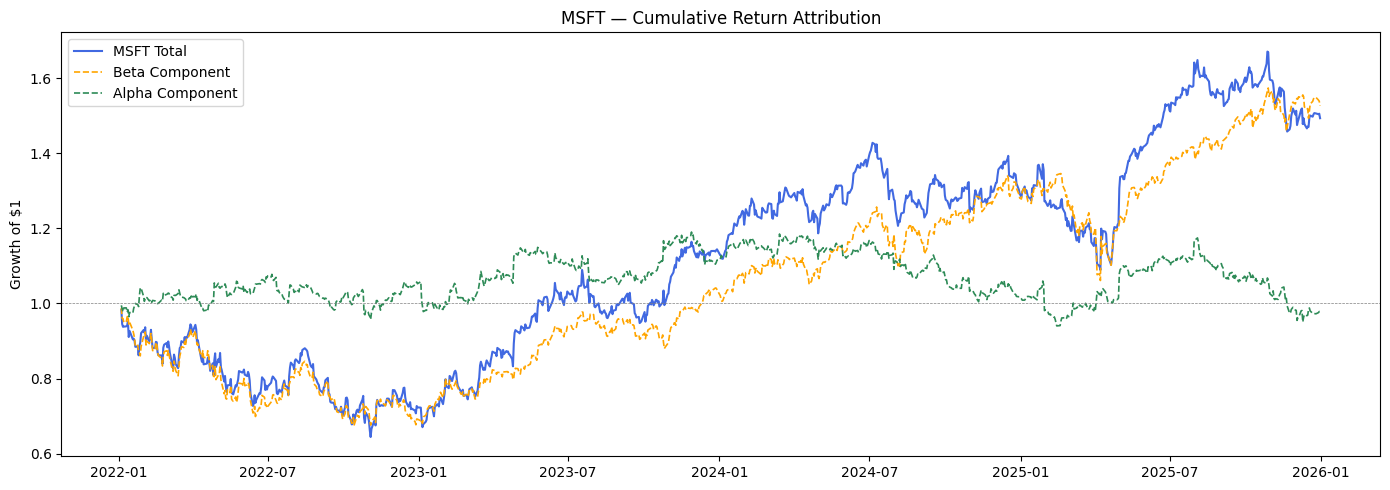

In [63]:
combined["Beta_return"] = beta * combined["Bench_return"]
combined["Alpha_return"] = combined["Daily_return"] - combined["Beta_return"]

# Cumulative attribution
combined["Cum_beta"]  = (1 + combined["Beta_return"]).cumprod()
combined["Cum_alpha"] = (1 + combined["Alpha_return"]).cumprod()

plt.figure(figsize=(14, 5))
plt.plot(combined["Cum_stock"], color="royalblue", linewidth=1.5, label=f"{tickers} Total")
plt.plot(combined["Cum_beta"],  color="orange",    linewidth=1.2, linestyle="--", label="Beta Component")
plt.plot(combined["Cum_alpha"], color="seagreen",  linewidth=1.2, linestyle="--", label="Alpha Component")
plt.axhline(1.0, color="gray", linestyle="--", linewidth=0.5)
plt.title(f"{tickers} — Cumulative Return Attribution")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

(If the alpha line trends up over time the stock is consistently generating returns beyond what QQQ exposure alone explains. That's the signal you want to isolate.)

7. Annual Return Breakdown

Year by year comparison of stock vs benchmark.

In [64]:
combined["Year"] = combined.index.year

annual = combined.groupby("Year").apply(
    lambda x: pd.Series({
        "Stock_return":  (1 + x["Daily_return"]).prod() - 1,
        "Bench_return":  (1 + x["Bench_return"]).prod() - 1,
        "Alpha_return":  (1 + x["Alpha_return"]).prod() - 1,
    })
).reset_index()

print(annual.round(4).to_string(index=False))

 Year  Stock_return  Bench_return  Alpha_return
 2022       -0.2769       -0.3322        0.0524
 2023        0.5819        0.5486        0.0597
 2024        0.1293        0.2558       -0.0875
 2025        0.1558        0.2077       -0.0389


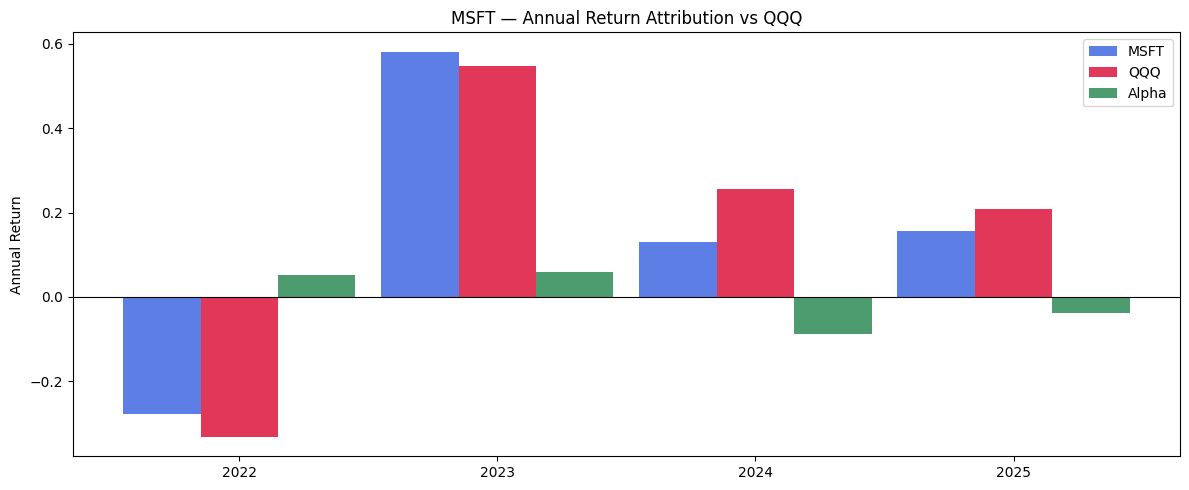

In [74]:
x = np.arange(len(annual))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, annual["Stock_return"], width, label=tickers,     color="royalblue", alpha=0.85)
ax.bar(x,         annual["Bench_return"], width, label=benchmark,  color="crimson",    alpha=0.85)
ax.bar(x + width, annual["Alpha_return"], width, label="Alpha",    color="seagreen",  alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(annual["Year"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{tickers} — Annual Return Attribution vs {benchmark}")
ax.set_ylabel("Annual Return")
ax.legend()
plt.tight_layout()
plt.show()

Attribution Summary Table

In [66]:
total_stock = combined["Cum_stock"].iloc[-1] - 1
total_bench = combined["Cum_bench"].iloc[-1] - 1
total_alpha = combined["Cum_alpha"].iloc[-1] - 1
total_beta  = combined["Cum_beta"].iloc[-1]  - 1

ann_stock = (1 + total_stock) ** (1/5) - 1
ann_bench = (1 + total_bench) ** (1/5) - 1
ann_alpha = (1 + total_alpha) ** (1/5) - 1

print(f"\nPerformance Attribution Summary — {tickers} vs {benchmark}")
print(f"{'='*50}")
print(f"{'Metric':<30} {tickers:>8}  {benchmark:>8}  {'Alpha':>8}")
print(f"{'-'*50}")
print(f"{'Total Return':<30} {total_stock:>8.2%}  {total_bench:>8.2%}  {total_alpha:>8.2%}")
print(f"{'Annualized Return':<30} {ann_stock:>8.2%}  {ann_bench:>8.2%}  {ann_alpha:>8.2%}")
print(f"{'Sharpe Ratio':<30} {sharpe:>8.4f}")
print(f"{'Sortino Ratio':<30} {sortino:>8.4f}")
print(f"{'Max Drawdown':<30} {mdd:>8.2%}")
print(f"{'Beta':<30} {beta:>8.4f}")
print(f"{'Jensen Alpha':<30} {alpha:>8.4f}")


Performance Attribution Summary — MSFT vs QQQ
Metric                             MSFT       QQQ     Alpha
--------------------------------------------------
Total Return                     49.31%    56.84%    -2.20%
Annualized Return                 8.35%     9.42%    -0.44%
Sharpe Ratio                     0.3233
Sortino Ratio                    0.4787
Max Drawdown                    -34.45%
Beta                             0.9222
Jensen Alpha                     0.0026
